In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/1Money_20_04_2026.csv")
df.head(10)

,ДАТА,ТИП,СО СЧЁТА,НА СЧЁТ / НА КАТЕГОРИЮ,СУММА,ВАЛЮТА,СУММА 2,ВАЛЮТА 2,МЕТКИ,ЗАМЕТКИ
0,20.04.2026,Перевод,Карта,Нерегуляр 🤡,4000.0,RUB,4000.0,RUB,NaN,NaN
1,20.04.2026,Перевод,Карта,Подушка ☠️,10000.0,RUB,10000.0,RUB,NaN,NaN
2,20.04.2026,Перевод,Карта,Аренда 🏠,2000.0,RUB,2000.0,RUB,NaN,NaN
3,20.04.2026,Доход,Карта,Бонусы,1408.0,RUB,1408.0,RUB,NaN,Проценты по старой подушке с Тиньков
4,20.04.2026,Расход,Карта,Продукты (Продукты),60.0,RUB,60.0,RUB,NaN,NaN
5,20.04.2026,Расход,Карта,Кафе (Кофейня),300.0,RUB,300.0,RUB,NaN,NaN
6,20.04.2026,Доход,Карта,Зарплата,36366.0,RUB,36366.0,RUB,NaN,Аванс
7,19.04.2026,Расход,Карта,Кафе (Кофейня),270.0,RUB,270.0,RUB,NaN,NaN
8,19.04.2026,Расход,Карта,Продукты (Продукты),810.0,RUB,810.0,RUB,NaN,NaN
9,19.04.2026,Расход,Карта,ВелоШокс,2290.0,RUB,2290.0,RUB,NaN,Флягодержатели и титановые болты


In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
df.tail(20)

In [ ]:
df["ДАТА"] = pd.to_datetime(df["ДАТА"], format="%d.%m.%Y", errors="coerce")
df["ДАТА"].head()

In [ ]:
df = df[df["ДАТА"].notna()].copy()
df.shape

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
df["ТИП"].value_counts()

In [ ]:
df["year"] = df["ДАТА"].dt.year
df["month"] = df["ДАТА"].dt.month
df["day_name"] = df["ДАТА"].dt.day_name()

df[["ДАТА", "year", "month", "day_name"]].head(10)

In [ ]:
df

In [ ]:
df["СУММА"].sum()

In [ ]:
df["СУММА"].mean()

In [ ]:
df["СУММА"].describe()

In [ ]:
df.sort_values("СУММА", ascending=False).tail(10)

In [ ]:
df["ТИП"].value_counts()

expenses = df[df["ТИП"] == "Расход"].copy()
income = df[df["ТИП"] == "Доход"].copy()
transfers = df[df["ТИП"] == "Перевод"].copy()

expenses.shape, income.shape, transfers.shape

expenses

In [ ]:
expenses.groupby("НА СЧЁТ / НА КАТЕГОРИЮ")["СУММА"].sum().sort_values(ascending=False).head(15)

In [ ]:
expenses["НА СЧЁТ / НА КАТЕГОРИЮ"].value_counts().head(15)

In [ ]:
monthly_expenses = expenses.groupby(["year", "month"])["СУММА"].sum()
monthly_expenses

In [121]:
monthly_income = income.groupby(["year", "month"])["СУММА"].sum()
monthly_income

year  month
2025  2          12000.0
      3         129110.0
      4         123550.0
      5         482617.0
      6         156600.0
      7         131500.0
      8         505816.0
      9        1187000.0
      10        337554.0
      11        162006.0
      12        236486.0
2026  1         144700.0
      2         119000.0
      3        1188077.0
      4         356350.0
Name: СУММА, dtype: float64

In [115]:
monthly_cashflow = pd.DataFrame({
    "income": monthly_income,
    "expenses": monthly_expenses,
}).fillna(0)

monthly_cashflow["net"] = monthly_cashflow["income"] - monthly_cashflow["expenses"]
monthly_cashflow

income  expenses        net
year month                                
2025 2        12000.0    9382.0     2618.0
     3       129110.0   83471.0    45639.0
     4       123550.0   79931.0    43619.0
     5       482617.0  198810.0   283807.0
     6       156600.0  103645.0    52955.0
     7       131500.0  130541.0      959.0
     8       505816.0  196917.0   308899.0
     9      1187000.0  130861.0  1056139.0
     10      337554.0  241410.0    96144.0
     11      162006.0  130405.0    31601.0
     12      236486.0  310306.0   -73820.0
2026 1       144700.0  114330.0    30370.0
     2       119000.0  161500.0   -42500.0
     3      1188077.0  155200.0  1032877.0
     4       356350.0  280128.0    76222.0

In [ ]:
expenses.groupby("НА СЧЁТ / НА КАТЕГОРИЮ")["СУММА"]\
    .sum()\
    .sort_values(ascending=False)\
    .head(15)\
    .plot(kind="bar", figsize=(12, 5))

plt.title("Top expense categories")
plt.ylabel("Total amount")
plt.show()

In [ ]:
expenses["СУММА"].plot(kind="hist", bins=30)
plt.title("Distribution of expense amounts")
plt.xlabel("Amount")
plt.show()

In [ ]:
expenses["СУММА"].plot(kind="box")
plt.title("Expense amount boxplot")
plt.ylabel("Amount")
plt.show()

In [ ]:
monthly_expenses.plot(kind="bar", figsize=(12, 5))
plt.title("Monthly expenses")
plt.ylabel("Total amount")
plt.show()

In [ ]:
monthly_cashflow["net"].plot(kind="bar", figsize=(12, 5))
plt.title("Monthly net cashflow")
plt.ylabel("Net")
plt.show()

In [10]:
# Task A
df.shape
df.columns
df.info()
df.tail(20)

,ДАТА,ТИП,СО СЧЁТА,НА СЧЁТ / НА КАТЕГОРИЮ,СУММА,ВАЛЮТА,СУММА 2,ВАЛЮТА 2,МЕТКИ,ЗАМЕТКИ
2008,Аренда 🏠,30220,RUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009,Хобби,0,RUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010,Наличные,0,RUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011,🍄 Не купил — накопил 🍄,350,RUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012,Подушка ☠️,10000,RUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013,Вклад ОЗОН банк,912918,RUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014,Шоссейник 🚳,0,RUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015,Вклад Tinkoff,0,RUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016,ПИФ Raiff,25221,RUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017,Михаил Окулов,57100,RUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
# Task B
df["ДАТА"] = pd.to_datetime(df["ДАТА"], format="%d.%m.%Y", errors="coerce")
df = df[df["ДАТА"].notna()].copy()
df.tail(10)

,ДАТА,ТИП,СО СЧЁТА,НА СЧЁТ / НА КАТЕГОРИЮ,СУММА,ВАЛЮТА,СУММА 2,ВАЛЮТА 2,МЕТКИ,ЗАМЕТКИ
1993,2025-02-26,Расход,Карта,Спорт (Напитки),125.0,RUB,125.0,RUB,NaN,NaN
1994,2025-02-26,Расход,Подушка ☠️,Мем,500.0,RUB,500.0,RUB,NaN,NaN
1995,2025-02-25,Расход,Подушка ☠️,Мем,1800.0,RUB,1800.0,RUB,NaN,NaN
1996,2025-02-24,Перевод,Подушка ☠️,Дошикс,5000.0,RUB,5000.0,RUB,NaN,До марта
1997,2025-02-24,Расход,Карта,Продукты (Продукты),648.0,RUB,648.0,RUB,NaN,NaN
1998,2025-02-24,Расход,Карта,Кафе (Кофейня),190.0,RUB,190.0,RUB,NaN,NaN
1999,2025-02-24,Перевод,Подушка ☠️,Карта,1000.0,RUB,1000.0,RUB,NaN,NaN
2000,2025-02-24,Расход,Карта,Продукты (Вода),658.0,RUB,658.0,RUB,NaN,NaN
2001,2025-02-24,Перевод,Подушка ☠️,Карта,1000.0,RUB,1000.0,RUB,NaN,NaN
2002,2025-02-23,Расход,Карта,Продукты (Кофе),1320.0,RUB,1320.0,RUB,NaN,NaN


In [49]:
# Task C
df["year"] = df["ДАТА"].dt.year
df["month"] = df["ДАТА"].dt.month
df["day_name"] = df["ДАТА"].dt.day_name()

df[["year", "month", "day_name"]].head(10)

,year,month,day_name
0,2026,4,Monday
1,2026,4,Monday
2,2026,4,Monday
3,2026,4,Monday
4,2026,4,Monday
5,2026,4,Monday
6,2026,4,Monday
7,2026,4,Sunday
8,2026,4,Sunday
9,2026,4,Sunday


ТИП
Расход     1648
Перевод     284
Доход        71
Name: count, dtype: int64

In [123]:
# Task D
df["ТИП"].value_counts()
expenses = df[df["ТИП"] == "Расход"].copy()
income = df[df["ТИП"] == "Доход"].copy()
transfers = df[df["ТИП"] == "Перевод"].copy()

expenses.shape, income.shape, transfers.shape
expenses

,ДАТА,ТИП,СО СЧЁТА,НА СЧЁТ / НА КАТЕГОРИЮ,СУММА,ВАЛЮТА,СУММА 2,ВАЛЮТА 2,МЕТКИ,ЗАМЕТКИ,year,month,day_name
4,2026-04-20,Расход,Карта,Продукты (Продукты),60.0,RUB,60.0,RUB,NaN,NaN,2026,4,Monday
5,2026-04-20,Расход,Карта,Кафе (Кофейня),300.0,RUB,300.0,RUB,NaN,NaN,2026,4,Monday
7,2026-04-19,Расход,Карта,Кафе (Кофейня),270.0,RUB,270.0,RUB,NaN,NaN,2026,4,Sunday
8,2026-04-19,Расход,Карта,Продукты (Продукты),810.0,RUB,810.0,RUB,NaN,NaN,2026,4,Sunday
9,2026-04-19,Расход,Карта,ВелоШокс,2290.0,RUB,2290.0,RUB,NaN,Флягодержатели и титановые болты,2026,4,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2025-02-25,Расход,Подушка ☠️,Мем,1800.0,RUB,1800.0,RUB,NaN,NaN,2025,2,Tuesday
1997,2025-02-24,Расход,Карта,Продукты (Продукты),648.0,RUB,648.0,RUB,NaN,NaN,2025,2,Monday
1998,2025-02-24,Расход,Карта,Кафе (Кофейня),190.0,RUB,190.0,RUB,NaN,NaN,2025,2,Monday
2000,2025-02-24,Расход,Карта,Продукты (Вода),658.0,RUB,658.0,RUB,NaN,NaN,2025,2,Monday


In [124]:
# Task E
expenses["СУММА"].sum()
expenses["СУММА"].mean()

expenses.groupby("НА СЧЁТ / НА КАТЕГОРИЮ")["СУММА"].sum().sort_values(ascending=False).head(15)
expenses["НА СЧЁТ / НА КАТЕГОРИЮ"].value_counts().head(15)

НА СЧЁТ / НА КАТЕГОРИЮ
Продукты (Продукты)     451
Кафе (Кофейня)          352
Кафе (Еда)              169
Продукты                 62
Покупки (Разное)         54
ВелоШокс                 48
Покупки                  47
Продукты (Вода)          42
Здоровье (Препараты)     37
Здоровье (Услуги)        33
Хата                     31
Покупки (Подписки)       31
Мем                      30
Интернет                 29
Покупки (Услуги)         27
Name: count, dtype: int64

In [158]:
# Task F
monthly_expenses = expenses.groupby(["year", "month"])["СУММА"].sum()
monthly_expenses

monthly_income = income.groupby(["year", "month"])["СУММА"].sum()
monthly_income

monthly_cashflow = pd.DataFrame({
    "income": monthly_income,
    "expenses": monthly_expenses
}).fillna(0)

monthly_cashflow["net"] = monthly_cashflow["income"] - monthly_cashflow["expenses"]
monthly_cashflow

income  expenses       net
year month                              
2025 2           0.0    9382.0   -9382.0
     3       83334.0   83471.0    -137.0
     4       90636.0   79931.0   10705.0
     5       82395.0  198810.0 -116415.0
     6      132701.0  103645.0   29056.0
     7       91931.0  130541.0  -38610.0
     8      450749.0  196917.0  253832.0
     9       83983.0  130861.0  -46878.0
     10     144064.0  241410.0  -97346.0
     11      34842.0  130405.0  -95563.0
     12     244772.0  310306.0  -65534.0
2026 1       41560.0  114330.0  -72770.0
     2      126073.0  161500.0  -35427.0
     3      272346.0  155200.0  117146.0
     4      291712.0  280128.0   11584.0

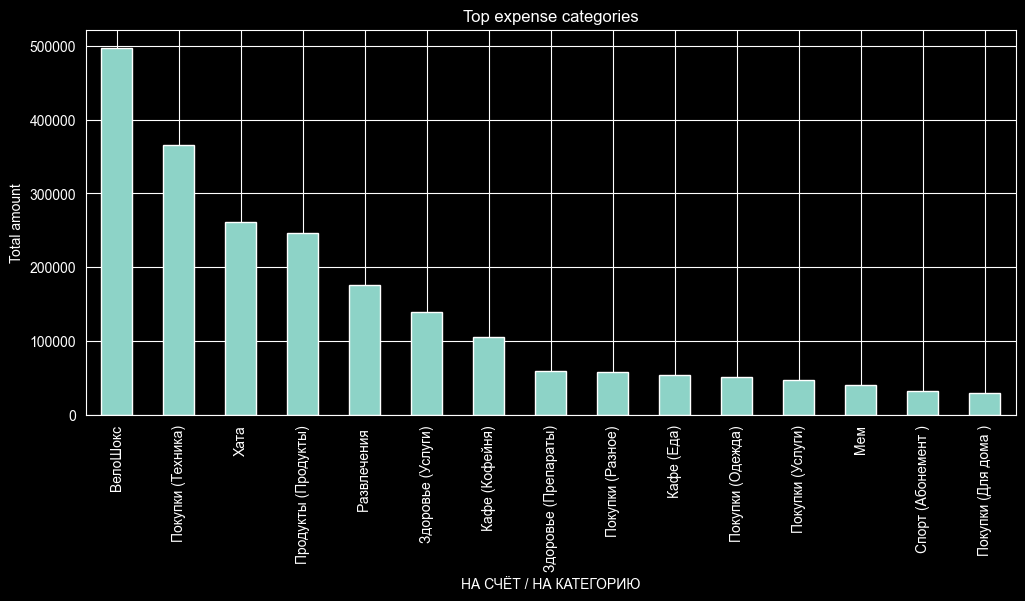

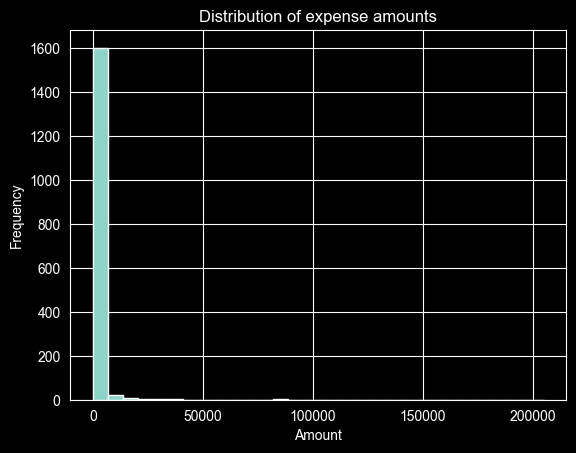

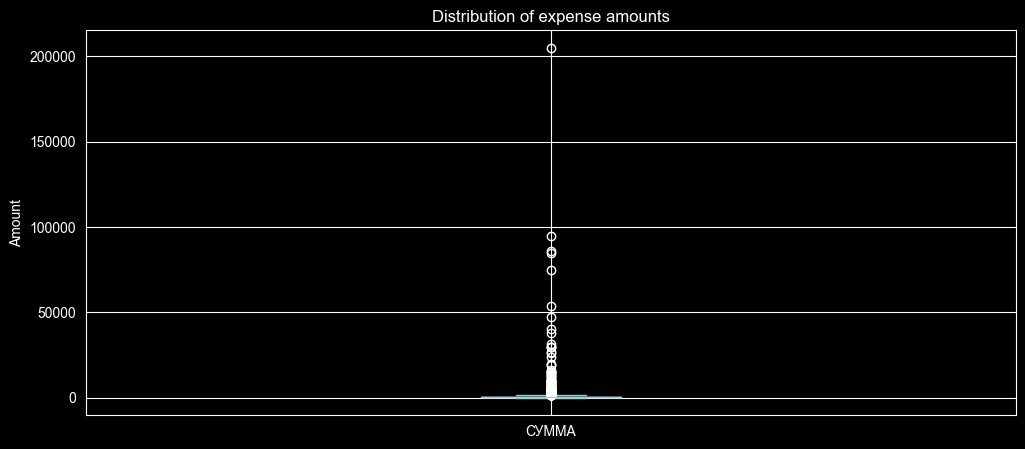

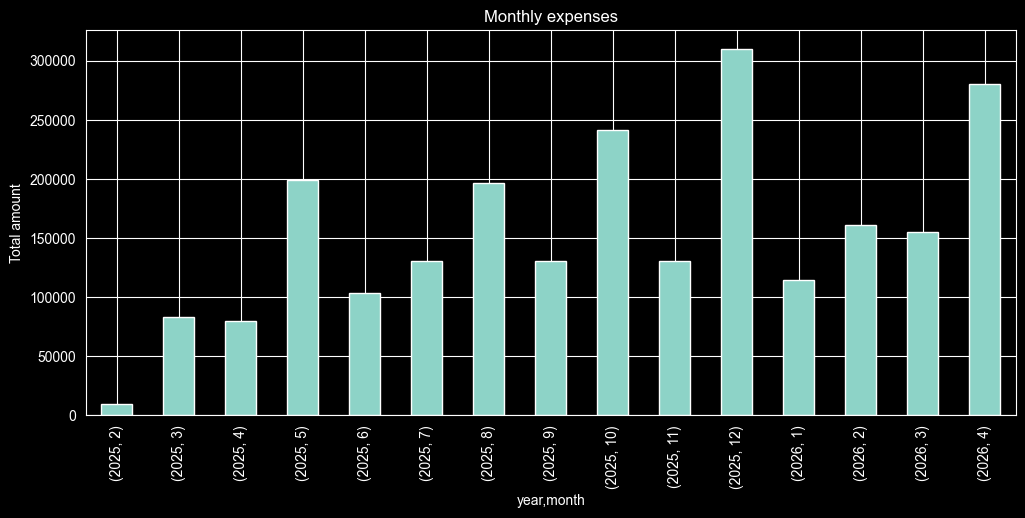

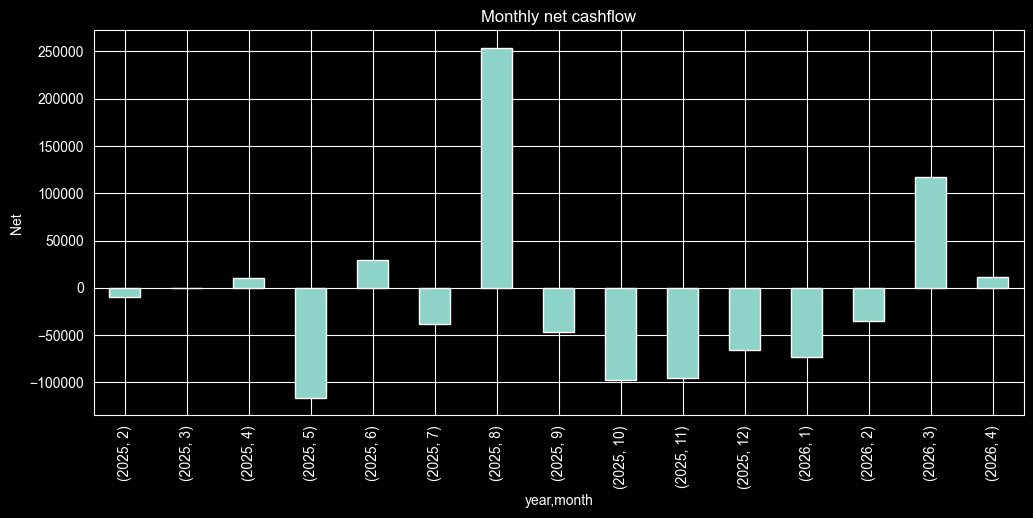

In [159]:
# Task G
expenses.groupby("НА СЧЁТ / НА КАТЕГОРИЮ")["СУММА"].sum().sort_values(ascending=False).head(15).plot(kind="bar", figsize=(12, 5))
plt.title("Top expense categories")
plt.ylabel("Total amount")
plt.show()

expenses["СУММА"].plot(kind="hist", bins=30)
plt.title("Distribution of expense amounts")
plt.xlabel("Amount")
plt.show()

expenses["СУММА"].plot(kind="box", figsize=(12, 5))
plt.title("Distribution of expense amounts")
plt.ylabel("Amount")
plt.show()

monthly_expenses.plot(kind="bar", figsize=(12, 5))
plt.title("Monthly expenses")
plt.ylabel("Total amount")
plt.show()

monthly_cashflow["net"].plot(kind="bar", figsize=(12, 5))
plt.title("Monthly net cashflow")
plt.ylabel("Net")
plt.show()

## Выводы

- В исходном CSV был служебный хвост, поэтому перед анализом пришлось очищать данные по валидности даты.
- Разделение на расходы, доходы и переводы критично: переводы не отражают реальные траты.
- Категории по сумме и по количеству дают разную картину: крупные разовые траты и частые мелкие траты — это разные паттерны.
- Анализ по месяцам и расчет net помогают понять, в какие периоды бюджет был под давлением.
- Даже без ML такой EDA уже полезен для изменения стратегии расходов и накоплений.